In [1]:
!pip install koreanize-matplotlib sdv catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.1/198.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/2

In [2]:
import pandas as pd
import numpy as np
import warnings
from dateutil.relativedelta import relativedelta
from bisect import bisect_left, bisect_right
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/거래_이상탐지_프로젝트/data'

Mounted at /content/drive/


In [4]:
train_df = pd.read_csv(path+"/fraudTrain.csv")
test_df = pd.read_csv(path+"/fraudTest.csv")

In [5]:
def calculate_age(born, trans_date):
    return relativedelta(trans_date, born).years

def count_past_days_fast(df, days):
    results = []
    grouped = df.groupby('cc_num')

    for card, group in grouped:
        times = group['trans_date_trans_time'].tolist()
        counts = []
        for i, t in enumerate(times):
            start_time = t - pd.Timedelta(days=days)
            # 왼쪽 경계 (start_time 이상)
            left_idx = bisect_left(times, start_time)
            # 오른쪽 경계는 현재 거래 바로 전(i번째 거래 제외)
            right_idx = i
            counts.append(right_idx - left_idx)
        results.extend(counts)
    return results

def preprocess_data(df: pd.DataFrame,
                    hour: str = 'sincos',
                    high_risk_period: bool = False,
                    age_group: bool = False
                    ) -> pd.DataFrame:
    '''
    Arg)
    df : 데이터프레임
    hour : 시간 전처리방법 (sincos : sin/cos 변환 , is_night : 'is_night' 칼럼 사용)
    high_risk_period : high_risk_period 사용여부 (Default : False)
    age_group : age_group 사용여부 (Default : False)
    '''

    # 원본 데이터프레임 복사
    df_p = df.copy()

    drop_cols = ['Unnamed: 0', 'unix_time', 'trans_num', 'first', 'last', 'merchant', 'street', 'merch_lat', 'merch_long', 'city_pop', 'lat', 'long', 'zip']
    df_p = df_p.drop(columns=drop_cols)

    # 로그 변환
    df_p['amt_log'] = np.log1p(df_p['amt'])

    # 표준화
    scaler = StandardScaler()
    df_p['amt_log_std'] = scaler.fit_transform(df_p[['amt_log']])

    # datetime 변환
    df_p['datetime'] = pd.to_datetime(df_p['trans_date_trans_time'])

    # 시(hour) 추출 (0~23)
    df_p['hour'] = df_p['datetime'].dt.hour

    # 요일 추출: Monday=0, Sunday=6
    df_p['day_of_week'] = df_p['datetime'].dt.dayofweek

    # 월 추출: 1월=1, 12월=12
    df_p['month'] = df_p['datetime'].dt.month

    # Hour : SinCos변환 or Is_night 사용
    if hour == 'sincos':
        df_p['trans_hour_sin'] = np.sin(2 * np.pi * df_p['hour'] / 24)
        df_p['trans_hour_cos'] = np.cos(2 * np.pi * df_p['hour'] / 24)
    elif hour == 'is_night':
        df_p['is_night'] = df_p['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)


    # higt_rist_period 사용여부
    if high_risk_period:
        # 금(4), 목(3), 수(2) + 심야 시간대(0~4, 21~23)
        high_risk_days = [2, 3, 4]  # 수, 목, 금
        high_risk_hours = list(range(0, 5)) + [21, 22, 23]

        df_p['is_high_risk_period'] = (
            df_p['day_of_week'].isin(high_risk_days) & df_p['hour'].isin(high_risk_hours)
        ).astype(int)

    df_p['trans_date_trans_time'] = pd.to_datetime(df_p['trans_date_trans_time'])
    df_p = df_p.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

    df_p['cnt_1d'] = count_past_days_fast(df_p, 1)
    df_p['cnt_7d'] = count_past_days_fast(df_p, 7)
    df_p['cnt_30d'] = count_past_days_fast(df_p, 30)

    df_p['next_trans_time'] = df_p.groupby('cc_num')['trans_date_trans_time'].shift(-1)
    df_p['time_since_last_trans'] = (df_p['trans_date_trans_time'] - df_p.groupby('cc_num')['trans_date_trans_time'].shift(1)).dt.total_seconds()

    # 또는 마지막 거래 이후 경과 시간(다음 거래까지 시간 간격)
    df_p['time_until_next_trans'] = (df_p['next_trans_time'] - df_p['trans_date_trans_time']).dt.total_seconds()

    # 결측치 처리 (time_since_last_trans 첫 거래는 NaN, 0으로 채우거나 다른 방식)
    df_p[['time_since_last_trans', 'time_until_next_trans']] = df_p[['time_since_last_trans', 'time_until_next_trans']].fillna(0)


    df_p['dob'] = pd.to_datetime(df_p['dob'])

    df_p['age'] = df_p.apply(lambda x: calculate_age(x['dob'], x['trans_date_trans_time']), axis=1)

    if age_group:
        df_p['age_group'] = (df_p['age'] // 10) * 10
        df_p = df_p.drop(columns=['age'])


    # Job 칼럼 Target Encoding + Smoothing ( 아직 없음 )

    df_p['city_state'] = df_p['city'] + ', ' + df_p['state']

    # 최종 Drop
    drop_cols = ['trans_date_trans_time', 'dob', 'next_trans_time', 'cc_num', 'datetime', 'time_until_next_trans', 'city', 'state', 'amt', 'amt_log', 'hour']
    df_p = df_p.drop(columns=drop_cols)

    return df_p

In [6]:
# K-Fold, 타겟 인코딩 스무딩 함수
def m_estimate_smoothing(mean, global_mean, count, m):
    """M-estimate 스무딩을 적용하여 평균을 계산합니다."""
    return (mean * count + global_mean * m) / (count + m)

def kfold_target_encoding(df, target_col, cat_cols, n_splits=5, m_param=10):
    """
    K-Fold 교차 검증 방식의 타겟 인코딩을 M-estimate 스무딩과 함께 적용합니다.
    주어진 cat_cols 리스트에 있는 모든 컬럼에 대해 OOF 인코딩을 적용하고,
    각 컬럼에 대한 Full 인코딩 맵과 전역 평균을 반환합니다.

    Args:
        df: 입력 데이터프레임 (훈련 데이터).
        target_col: 타겟 컬럼 이름 (예: 'is_fraud').
        cat_cols: 인코딩하고 값을 덮어쓸 범주형 컬럼 이름의 리스트.
        n_splits: K-Fold 분할 개수.
        m_param: M-estimate 스무딩 파라미터.
    Returns:
        tuple: (OOF 인코딩된 DataFrame, 각 컬럼별 Full 인코딩 맵과 전역 평균을 담은 딕셔너리)
    """
    df_processed = df.copy() # 원본 DataFrame을 직접 수정하지 않기 위해 복사본 사용
    global_mean = df_processed[target_col].mean() # 전체 타겟 변수의 평균 (모든 인코딩에 공통 사용)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 각 범주형 컬럼별로 학습된 Full 인코딩 맵과 전역 평균을 저장할 딕셔너리
    all_learned_encoding_info = {}

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols: # 각 범주형 컬럼에 대해 반복 처리
        print(f"--- '{cat_col}' 컬럼 OOF 인코딩 진행 중 ---")
        temp_oof_encoded_values = np.empty(len(df_processed))
        temp_oof_encoded_values[:] = np.nan # 초기화

        for train_idx, valid_idx in kf.split(df_processed):
            train_fold = df_processed.iloc[train_idx]

            # 훈련 폴드에서 해당 cat_col의 평균 및 개수 집계
            agg = train_fold.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()

            # M-estimate 스무딩 적용
            agg['smoothed'] = m_estimate_smoothing(agg['mean'], global_mean, agg['count'], m_param)
            mapping = dict(zip(agg[cat_col], agg['smoothed']))

            # 유효성 검사 폴드의 해당 cat_col 위치에 스무딩된 값을 매핑
            temp_oof_encoded_values[valid_idx] = df_processed.loc[valid_idx, cat_col].map(mapping).fillna(global_mean)

        # 모든 폴드에 대한 처리가 끝난 후, df_processed에 OOF 인코딩된 값을 덮어씁니다.
        df_processed[cat_col] = temp_oof_encoded_values

        # 현재 컬럼에 대한 Full 인코딩 맵 생성 (테스트 데이터 인코딩에 사용될 예정)
        full_agg = df.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()
        full_agg['smoothed'] = m_estimate_smoothing(full_agg['mean'], global_mean, full_agg['count'], m_param)
        full_encoding_map = dict(zip(full_agg[cat_col], full_agg['smoothed']))

        # 각 컬럼의 맵과 전역 평균을 딕셔너리에 저장
        all_learned_encoding_info[cat_col] = {
            'map': full_encoding_map,
            'global_mean': global_mean # 각 컬럼별 전역 평균은 동일
        }

    return df_processed, all_learned_encoding_info # OOF 인코딩된 DF와 모든 Full 맵/전역 평균 정보 반환


def test_data_target_encoding(df, cat_cols, learned_encoding_info):
    """
    제공된 인코딩 맵과 전역 평균을 사용하여 테스트 데이터프레임의 여러 컬럼을 인코딩합니다.

    Args:
        df: 입력 데이터프레임 (테스트 데이터).
        cat_cols: 인코딩할 범주형 컬럼 이름의 리스트.
        learned_encoding_info: kfold_target_encoding에서 반환된 학습된 인코딩 정보를 담은 딕셔너리.
                               예: {'col1': {'map': map1, 'global_mean': gm1}, 'col2': {'map': map2, 'global_mean': gm2}}
    Returns:
        인코딩된 컬럼이 덮어씌워진 DataFrame.
    """
    df_processed = df.copy()

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols:
        if cat_col not in learned_encoding_info:
            print(f"경고: '{cat_col}' 컬럼에 대한 학습된 인코딩 정보가 없습니다. 해당 컬럼은 인코딩되지 않습니다.")
            continue

        encoding_map = learned_encoding_info[cat_col]['map']
        global_mean = learned_encoding_info[cat_col]['global_mean']

        # 인코딩 값 덮어쓰기: 맵에 없는 값은 해당 컬럼의 전역 평균으로 대체
        df_processed[cat_col] = df_processed[cat_col].map(encoding_map).fillna(global_mean)
        print(f"--- '{cat_col}' 컬럼 테스트 데이터 인코딩 완료 ---")

    return df_processed

In [7]:
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = test_df.copy()
print("데이터 분할 완료")
print(f"학습: {df_train.shape}, 검증: {df_val.shape}, 테스트: {df_test.shape}\n" + "-"*50)

데이터 분할 완료
학습: (1037340, 23), 검증: (259335, 23), 테스트: (555719, 23)
--------------------------------------------------


In [8]:
print("1차 기본 전처리 시작...")
# preprocess_data 함수가 이미 정의되어 있다고 가정합니다.
train_temp = preprocess_data(df_train, high_risk_period=True, age_group=False)
val_temp = preprocess_data(df_val, high_risk_period=True, age_group=False)
test_temp = preprocess_data(df_test, high_risk_period=True, age_group=False)
print("-> 1차 기본 전처리 완료.")

1차 기본 전처리 시작...
-> 1차 기본 전처리 완료.


In [9]:
print("\nK-Fold 타겟 인코딩 (Smoothing) 시작...")

encoding_features = ['job', 'city_state']
m_param_job = 500
m_param_city_state = 5
n_splits_kfold = 5

train_encoded, learned_info_job = kfold_target_encoding(
    df=train_temp, target_col='is_fraud', cat_cols=['job'],
    n_splits=n_splits_kfold, m_param=m_param_job
)
train_encoded, learned_info_cs = kfold_target_encoding(
    df=train_encoded, target_col='is_fraud', cat_cols=['city_state'],
    n_splits=n_splits_kfold, m_param=m_param_city_state
)

learned_info = {**learned_info_job, **learned_info_cs}

val_encoded = test_data_target_encoding(df=val_temp, cat_cols=encoding_features, learned_encoding_info=learned_info)
test_encoded = test_data_target_encoding(df=test_temp, cat_cols=encoding_features, learned_encoding_info=learned_info)

rename_dict = {'job': 'job_encoded', 'city_state': 'city_state_encoded'}
train_encoded.rename(columns=rename_dict, inplace=True)
val_encoded.rename(columns=rename_dict, inplace=True)
test_encoded.rename(columns=rename_dict, inplace=True)

print(f"\n-> 타겟 인코딩 완료: {list(rename_dict.values())}")


K-Fold 타겟 인코딩 (Smoothing) 시작...
--- 'job' 컬럼 OOF 인코딩 진행 중 ---
--- 'city_state' 컬럼 OOF 인코딩 진행 중 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---

-> 타겟 인코딩 완료: ['job_encoded', 'city_state_encoded']


In [10]:
print("\nCTGAN 데이터 증강 시작...")

# 타겟 인코딩만 완료된 학습 데이터로 증강 수행
fraud_data = train_encoded[train_encoded['is_fraud'] == 1]
non_fraud_data = train_encoded[train_encoded['is_fraud'] == 0]

if len(fraud_data) > 0:
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(data=fraud_data)

    # 주의: 이 단계에서는 아직 원핫 인코딩이 되지 않았으므로,
    # 'category'와 'gender'는 CTGAN이 자동으로 'categorical'로 처리하도록 둡니다.
    metadata.update_column(column_name='job_encoded', sdtype='numerical')
    metadata.update_column(column_name='city_state_encoded', sdtype='numerical')

    synthesizer = CTGANSynthesizer(
        metadata,
        epochs=100,
        batch_size=600,
        generator_lr=0.0006112310526245794,
        discriminator_lr= 9.854847972391991e-05,
        embedding_dim=128,
        verbose=False
    )
    synthesizer.fit(fraud_data)
    synthetic_fraud_data = synthesizer.sample(num_rows=100000)

    # 증강된 데이터와 원본 데이터를 합쳐 새로운 학습 데이터셋 생성
    train_aug = pd.concat([non_fraud_data, fraud_data, synthetic_fraud_data], ignore_index=True)
    train_aug = train_aug.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"-> 데이터 증강 완료 (최종 학습 데이터: {train_aug.shape})")
else:
    print("-> 학습 데이터에 사기 거래가 없어 증강을 건너뜁니다.")
    train_aug = train_encoded

# 검증 및 테스트 데이터는 이 단계에서 변경 없이 그대로 전달
val_pre_ohe = val_encoded
test_pre_ohe = test_encoded


CTGAN 데이터 증강 시작...
-> 데이터 증강 완료 (최종 학습 데이터: (1137340, 16))


In [11]:
print("\n원-핫 인코딩 시작...")
categorical_features = ['category', 'gender','day_of_week','is_high_risk_period']

# 증강된 학습 데이터셋에 원핫 인코딩 적용
train_final = pd.get_dummies(train_aug, columns=categorical_features, dummy_na=False, drop_first=True)
val_final = pd.get_dummies(val_pre_ohe, columns=categorical_features, dummy_na=False, drop_first=True)
test_final = pd.get_dummies(test_pre_ohe, columns=categorical_features, dummy_na=False, drop_first=True)

# 증강 후 생성된 학습 데이터 기준으로 컬럼 맞추기
train_cols = train_final.columns
val_final = val_final.reindex(columns=train_cols, fill_value=0)
test_final = test_final.reindex(columns=train_cols, fill_value=0)

print("-> 원-핫 인코딩 및 컬럼 정렬 완료.")


원-핫 인코딩 시작...
-> 원-핫 인코딩 및 컬럼 정렬 완료.


In [12]:
print("\n최종 데이터셋 생성 및 스케일링 시작...")

# 피처(X)와 타겟(y) 분리
X_train_final = train_final.drop('is_fraud', axis=1)
y_train_final = train_final['is_fraud']

X_val_final = val_final.drop('is_fraud', axis=1).reindex(columns=X_train_final.columns, fill_value=0)
y_val_final = val_final['is_fraud']

X_test_final = test_final.drop('is_fraud', axis=1).reindex(columns=X_train_final.columns, fill_value=0)
y_test_final = test_final['is_fraud']

# 최종 피처들에 대해 스케일러 학습 및 적용
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_val_scaled = scaler_final.transform(X_val_final)
X_test_scaled = scaler_final.transform(X_test_final)

print("-> 스케일링 완료.")
print("\n" + "="*50 + "\n모든 작업이 완료되었습니다.\n" + "="*50)
print("최종 학습 데이터 형태:", X_train_scaled.shape)
print("최종 검증 데이터 형태:", X_val_scaled.shape)
print("최종 테스트 데이터 형태:", X_test_scaled.shape)


최종 데이터셋 생성 및 스케일링 시작...
-> 스케일링 완료.

모든 작업이 완료되었습니다.
최종 학습 데이터 형태: (1137340, 32)
최종 검증 데이터 형태: (259335, 32)
최종 테스트 데이터 형태: (555719, 32)


In [13]:
param_1 = {
    'learning_rate': 0.05,
    'n_estimators': 3000,
    'max_depth': 10,
    'min_child_weight': 1,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_lambda': 1.0,
    'random_state' : 42,
    'n_jobs' : -1,
    'eval_metric' : 'aucpr',
    'tree_method' :'hist',
    'device' :'cuda',
    'use_label_encoder' : False
}

In [14]:
param_2 = {
    'n_estimators': 4944,
    'learning_rate': 0.06917383407985545,
    'max_depth': 6,
    'min_child_weight': 7,
    'gamma': 0.6919144601910644,
    'subsample': 0.7889560739409641,
    'colsample_bytree': 0.8421639076201854,
    'reg_alpha': 0.7000228879907439,
    'reg_lambda': 0.7786285622566288,
    'random_state' : 42,
    'n_jobs' : -1,
    'eval_metric' : 'aucpr',
    'tree_method' :'hist',
    'device' :'cuda',
    'use_label_encoder' : False

}

In [35]:
param_3 = {
    'n_estimators': 6510,
    'learning_rate': 0.031192542167490483,
    'max_depth': 11,
    'min_child_weight': 4,
    'gamma': 0.5789024869287231,
    'subsample': 0.8358031491782407,
    'colsample_bytree': 0.8033780543468922,
    'reg_alpha': 0.8518355954494826,
    'reg_lambda': 0.1001858659945743,
    'random_state' : 42,
    'n_jobs' : -1,
    'eval_metric' : 'aucpr',
    'tree_method' :'hist',
    'device' :'cuda',
    'use_label_encoder' : False
}

In [36]:
param_4 = {
    'n_estimators': 5695,
    'learning_rate': 0.0382401350044867,
    'max_depth': 10,
    'min_child_weight': 1,
    'gamma': 0.18162937834767517,
    'subsample': 0.7812421852775957,
    'colsample_bytree': 0.8219297446574406,
    'reg_alpha': 0.845666139665595,
    'reg_lambda': 0.009037530578151709,
    'random_state' : 42,
    'n_jobs' : -1,
    'eval_metric' : 'aucpr',
    'tree_method' :'hist',
    'device' :'cuda',
    'use_label_encoder' : False
}

In [29]:
print("\nXGBoost 모델을 학습합니다...")
# 찾은 best_params를 그대로 사용합니다.

xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='aucpr', use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train_final)
print("-> baseline 학습 완료.")


XGBoost 모델을 학습합니다...
-> baseline 학습 완료.


In [30]:
print("\nXGBoost 모델을 학습합니다...")
# 찾은 best_params를 그대로 사용합니다.

xgb_model1 = XGBClassifier(**param_1)
xgb_model1.fit(X_train_scaled, y_train_final)
print("-> 모델1 학습 완료.")


XGBoost 모델을 학습합니다...
-> 모델1 학습 완료.


In [31]:
print("\nXGBoost 모델을 학습합니다...")
# 찾은 best_params를 그대로 사용합니다.

xgb_model2 = XGBClassifier(**param_2)
xgb_model2.fit(X_train_scaled, y_train_final)
print("-> 모델2 학습 완료.")


XGBoost 모델을 학습합니다...
-> 모델2 학습 완료.


In [37]:
print("\nXGBoost 모델을 학습합니다...")
# 찾은 best_params를 그대로 사용합니다.

xgb_model3 = XGBClassifier(**param_3)
xgb_model3.fit(X_train_scaled, y_train_final)
print("-> 모델2 학습 완료.")


XGBoost 모델을 학습합니다...
-> 모델2 학습 완료.


In [38]:
print("\nXGBoost 모델을 학습합니다...")
# 찾은 best_params를 그대로 사용합니다.

xgb_model4 = XGBClassifier(**param_4)
xgb_model4.fit(X_train_scaled, y_train_final)
print("-> 모델2 학습 완료.")


XGBoost 모델을 학습합니다...
-> 모델2 학습 완료.


## 모델 평가 시각화

In [24]:
def evaluate_and_visualize(model, X_data, y_data, set_name):
    """모델 평가 및 결과/혼동 행렬 시각화 함수"""
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1]

    results = {
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred),
        'ROC_AUC': roc_auc_score(y_data, y_pred_proba)
    }

    print(f"\n--- {set_name} 평가 결과 ---")
    print(pd.DataFrame([results]).to_string())
    print("\nClassification Report:")
    print(classification_report(y_data, y_pred, digits=4))

    cm = confusion_matrix(y_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'])
    plt.title(f'Confusion Matrix ({set_name})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return results


XGBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.940092  0.815456   0.87335  0.997745

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9997    0.9993    257834
           1     0.9401    0.8155    0.8733      1501

    accuracy                         0.9986    259335
   macro avg     0.9695    0.9076    0.9363    259335
weighted avg     0.9986    0.9986    0.9986    259335



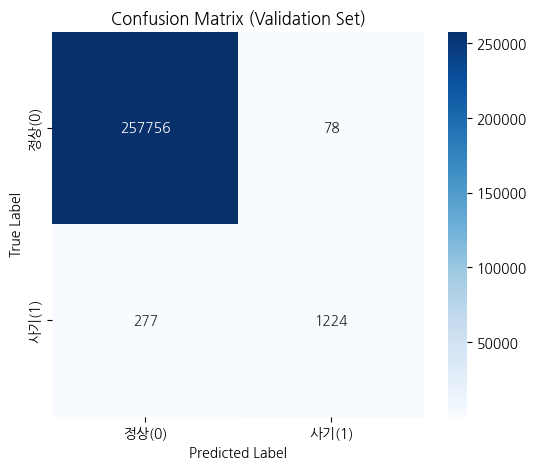


XGBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score  ROC_AUC
0   0.844231  0.409324  0.551334  0.97255

Classification Report:
              precision    recall  f1-score   support

           0     0.9977    0.9997    0.9987    553574
           1     0.8442    0.4093    0.5513      2145

    accuracy                         0.9974    555719
   macro avg     0.9210    0.7045    0.7750    555719
weighted avg     0.9971    0.9974    0.9970    555719



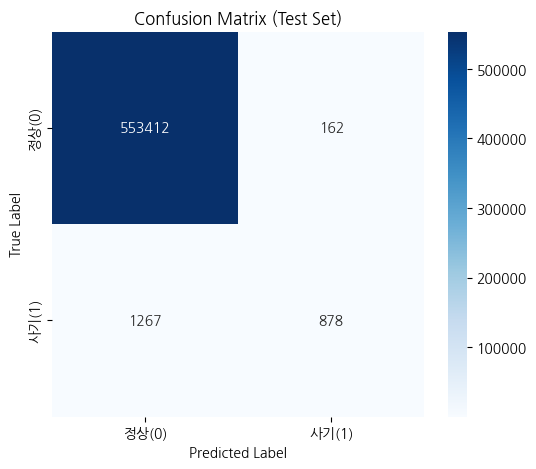

{'Precision': 0.8442307692307692,
 'Recall': 0.4093240093240093,
 'F1-Score': 0.5513343799058085,
 'ROC_AUC': np.float64(0.9725503271923444)}

In [32]:
# 검증 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(xgb_model, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(xgb_model, X_test_scaled, y_test_final, "Test Set")


XGBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.965764  0.808128  0.879942  0.998147

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9998    0.9994    257834
           1     0.9658    0.8081    0.8799      1501

    accuracy                         0.9987    259335
   macro avg     0.9823    0.9040    0.9397    259335
weighted avg     0.9987    0.9987    0.9987    259335



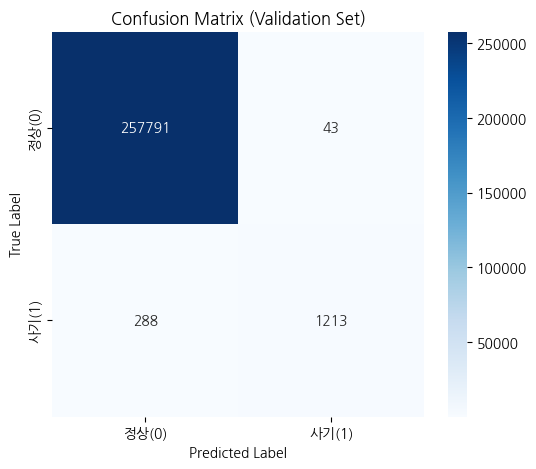


XGBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.912264  0.450816  0.603432  0.982299

Classification Report:
              precision    recall  f1-score   support

           0     0.9979    0.9998    0.9989    553574
           1     0.9123    0.4508    0.6034      2145

    accuracy                         0.9977    555719
   macro avg     0.9551    0.7253    0.8011    555719
weighted avg     0.9975    0.9977    0.9973    555719



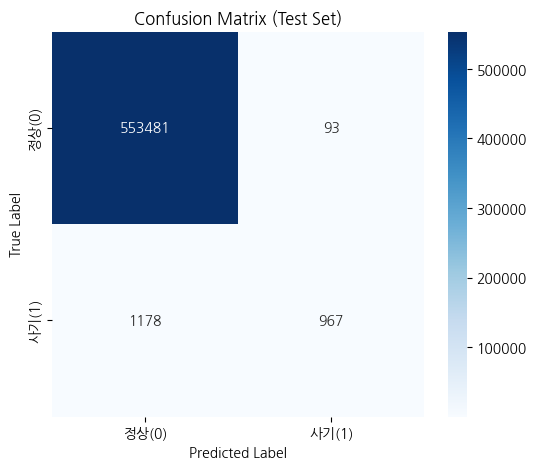

{'Precision': 0.9122641509433962,
 'Recall': 0.4508158508158508,
 'F1-Score': 0.6034321372854914,
 'ROC_AUC': np.float64(0.9822990654254407)}

In [33]:
# 검증 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(xgb_model1, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(xgb_model1, X_test_scaled, y_test_final, "Test Set")


XGBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.947005  0.821452  0.879772  0.998257

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9997    0.9993    257834
           1     0.9470    0.8215    0.8798      1501

    accuracy                         0.9987    259335
   macro avg     0.9730    0.9106    0.9396    259335
weighted avg     0.9987    0.9987    0.9987    259335



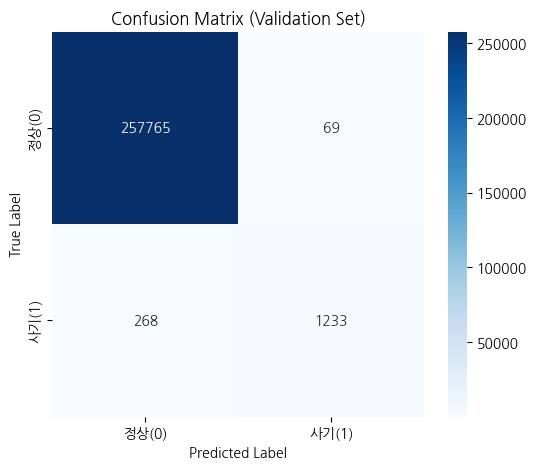


XGBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.868852  0.420047   0.56631  0.983483

Classification Report:
              precision    recall  f1-score   support

           0     0.9978    0.9998    0.9988    553574
           1     0.8689    0.4200    0.5663      2145

    accuracy                         0.9975    555719
   macro avg     0.9333    0.7099    0.7825    555719
weighted avg     0.9973    0.9975    0.9971    555719



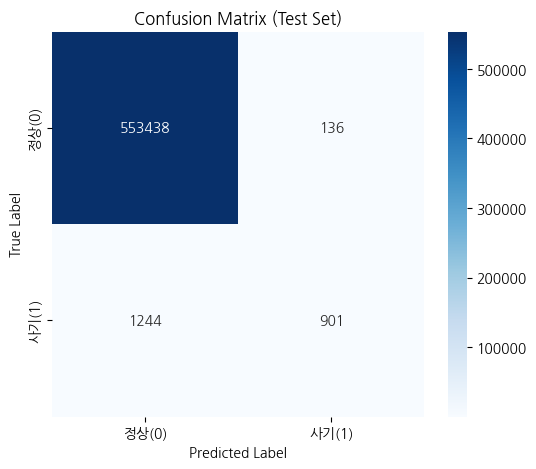

{'Precision': 0.8688524590163934,
 'Recall': 0.42004662004662,
 'F1-Score': 0.5663104965430547,
 'ROC_AUC': np.float64(0.9834832727526387)}

In [34]:
# 검증 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(xgb_model2, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(xgb_model2, X_test_scaled, y_test_final, "Test Set")


XGBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.946841  0.818787  0.878171  0.998467

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9997    0.9993    257834
           1     0.9468    0.8188    0.8782      1501

    accuracy                         0.9987    259335
   macro avg     0.9729    0.9093    0.9388    259335
weighted avg     0.9986    0.9987    0.9986    259335



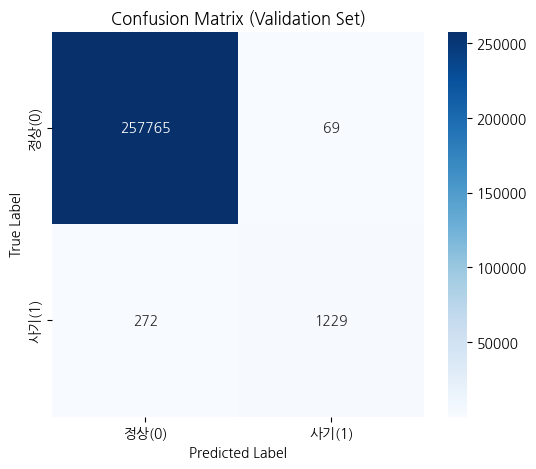


XGBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.863983  0.370163  0.518277  0.979056

Classification Report:
              precision    recall  f1-score   support

           0     0.9976    0.9998    0.9987    553574
           1     0.8640    0.3702    0.5183      2145

    accuracy                         0.9973    555719
   macro avg     0.9308    0.6850    0.7585    555719
weighted avg     0.9970    0.9973    0.9968    555719



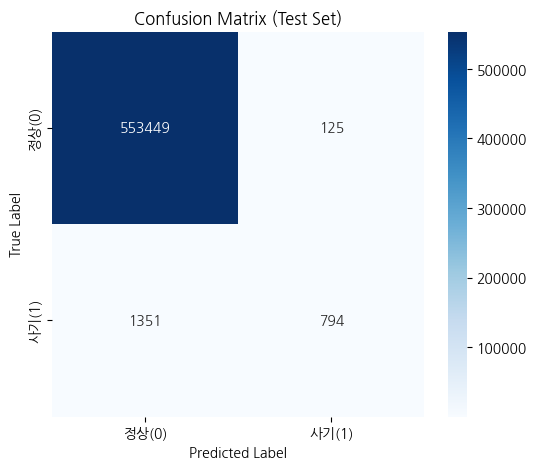

{'Precision': 0.8639825897714908,
 'Recall': 0.3701631701631702,
 'F1-Score': 0.5182767624020888,
 'ROC_AUC': np.float64(0.9790563031970685)}

In [39]:
# 검증 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(xgb_model3, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(xgb_model3, X_test_scaled, y_test_final, "Test Set")


XGBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.956829  0.812125  0.878559  0.998188

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9998    0.9993    257834
           1     0.9568    0.8121    0.8786      1501

    accuracy                         0.9987    259335
   macro avg     0.9779    0.9060    0.9390    259335
weighted avg     0.9987    0.9987    0.9986    259335



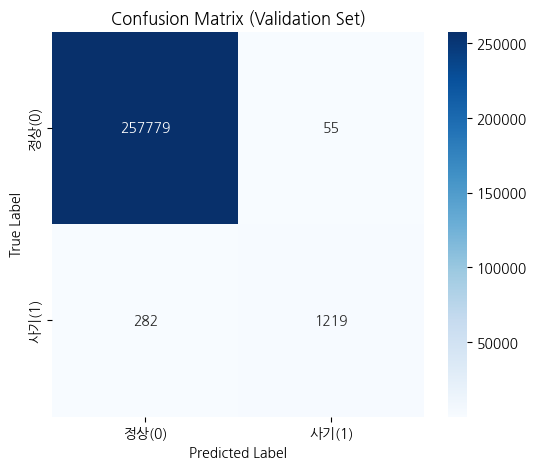


XGBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.903579  0.423776   0.57696  0.981255

Classification Report:
              precision    recall  f1-score   support

           0     0.9978    0.9998    0.9988    553574
           1     0.9036    0.4238    0.5770      2145

    accuracy                         0.9976    555719
   macro avg     0.9507    0.7118    0.7879    555719
weighted avg     0.9974    0.9976    0.9972    555719



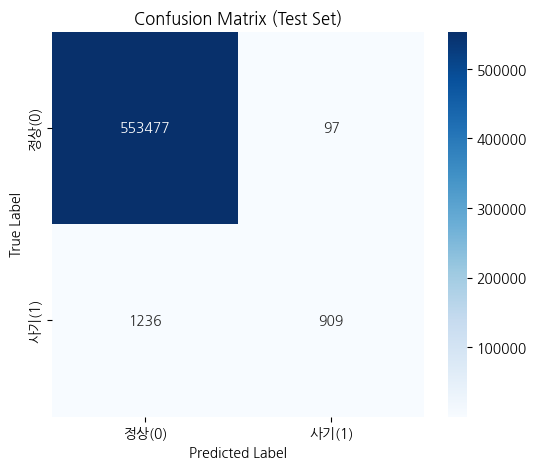

{'Precision': 0.9035785288270378,
 'Recall': 0.42377622377622376,
 'F1-Score': 0.5769596953348144,
 'ROC_AUC': np.float64(0.9812549218735203)}

In [40]:
# 검증 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(xgb_model4, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(xgb_model4, X_test_scaled, y_test_final, "Test Set")

# 1차 xgboost grid search

In [ ]:
param_grid = {
    'learning_rate': [0.05, 0.01],
    'n_estimators': [200, 500],
    'max_depth': [5, 7],
    'min_child_weight': [1, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1],
    'reg_lambda': [1.0, 10.0]
}

In [ ]:
# param_grid = {
#     'learning_rate': [0.1, 0.05, 0.01],
#     'n_estimators': [200, 500, 1000],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 5],
#     'subsample': [0.7, 0.8],
#     'colsample_bytree': [0.7, 0.8],
#     'gamma': [0, 0.1, 0.2],
#     'reg_lambda': [0.1, 1.0, 10.0]
# }

In [ ]:
import os

num_cpus = os.cpu_count()
print(f"현재 시스템의 CPU 코어/스레드 수: {num_cpus}개")

현재 시스템의 CPU 코어/스레드 수: 12개


In [ ]:
# --- 2. GridSearchCV 설정 (여러 평가지표를 추적) ---
scoring_metrics_dict = {
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
    'roc_auc': 'roc_auc'
}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    tree_method='gpu_hist', # GPU 사용 설정 시도
    random_state=42
)

print("GridSearchCV 시작 (여러 평가지표 추적)...")
print("GPU 사용을 시도합니다 (tree_method='gpu_hist').")
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring=scoring_metrics_dict, # 모든 지표를 추적합니다.
    refit='f1', # grid_search.best_estimator_는 F1-score 기준으로 최적화된 모델을 반환
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train_final)
print("GridSearchCV 완료.")

GridSearchCV 시작 (여러 평가지표 추적)...
GPU 사용을 시도합니다 (tree_method='gpu_hist').
Fitting 3 folds for each of 256 candidates, totalling 768 fits
GridSearchCV 완료.


In [ ]:
# --- 3. 각 평가지표별 '최적의 파라미터' 찾기 (교차 검증 결과 기반) ---
# 이 부분이 바로 'Validation에서 높은 것만 선택'하는 로직입니다.
# grid_search.cv_results_[f'mean_test_{scorer_key}']는 교차 검증의 평균 검증 점수를 의미합니다.
best_params_per_metric_cv = {} # CV 결과 기반 최적 파라미터
for metric_name, scorer_key in scoring_metrics_dict.items():
    best_idx = np.argmax(grid_search.cv_results_[f'mean_test_{scorer_key}'])
    best_params = grid_search.cv_results_['params'][best_idx]
    best_params_per_metric_cv[metric_name] = best_params
    print(f"\n[CV 기반] 최고 {metric_name.upper()} 점수 파라미터: {best_params}")
    print(f" 해당 교차 검증 평균 {metric_name.upper()} 점수: {grid_search.cv_results_[f'mean_test_{scorer_key}'][best_idx]:.4f}")

# --- 4. 각 '최적 모델'들을 학습시키고 검증 및 테스트 세트에서 평가, 그리고 리스트에 저장 ---
# 이 모델들은 모두 CV 결과에 따라 최적화된 파라미터를 사용합니다.
test_performance_data = {}
validation_performance_data = {}
saved_models_list = []
model_labels_in_list = [] # 리스트에 저장된 모델의 레이블 (어떤 지표에 최적화되었는지)

# X축 레이블을 명확히 정의 (GridSearchCV의 CV 결과에 따라 최적화된 모델임을 명시)
model_optimization_labels = [f'Optimized for {m.upper()} (CV)' for m in scoring_metrics_dict.keys()]

for metric_name_opt, params in best_params_per_metric_cv.items(): # metric_name_opt: 'f1', 'recall' 등 최적화 기준 지표
    print(f"\n--- {metric_name_opt.upper()} 최적화 모델 학습 및 평가 ---")

    current_best_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False,
        tree_method='gpu_hist',
        random_state=42,
        **params
    )
    current_best_model.fit(X_train_scaled, y_train_final)

    # --- Validation Set 평가 ---
    y_val_pred_proba = current_best_model.predict_proba(X_val_scaled)[:, 1]
    y_val_pred = current_best_model.predict(X_val_scaled)

    validation_performance_data[metric_name_opt] = {
        'f1': f1_score(y_val_final, y_val_pred),
        'recall': recall_score(y_val_final, y_val_pred),
        'precision': precision_score(y_val_final, y_val_pred),
        'roc_auc': roc_auc_score(y_val_final, y_val_pred_proba)
    }
    print(f"  --- Validation Set Performance ({metric_name_opt.upper()} Optimized Model) ---")
    for key, val in validation_performance_data[metric_name_opt].items():
        print(f"  Validation {key.upper()}: {val:.4f}")

    # --- Test Set 평가 ---
    y_test_pred_proba = current_best_model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = current_best_model.predict(X_test_scaled)

    test_performance_data[metric_name_opt] = {
        'f1': f1_score(y_test_final, y_test_pred),
        'recall': recall_score(y_test_final, y_test_pred),
        'precision': precision_score(y_test_final, y_test_pred),
        'roc_auc': roc_auc_score(y_test_final, y_test_pred_proba)
    }
    print(f"  --- Test Set Performance ({metric_name_opt.upper()} Optimized Model) ---")
    for key, val in test_performance_data[metric_name_opt].items():
        print(f"  Test {key.upper()}: {val:.4f}")

    saved_models_list.append(current_best_model)
    model_labels_in_list.append(f'model_optimized_for_{metric_name_opt}_cv_result')
    print(f"  모델이 리스트에 저장되었습니다. (총 {len(saved_models_list)}개 모델)")


[CV 기반] 최고 F1 점수 파라미터: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'reg_lambda': 1.0, 'subsample': 0.8}
 해당 교차 검증 평균 F1 점수: 0.9947

[CV 기반] 최고 RECALL 점수 파라미터: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'reg_lambda': 1.0, 'subsample': 0.8}
 해당 교차 검증 평균 RECALL 점수: 0.9912

[CV 기반] 최고 PRECISION 점수 파라미터: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 1.0, 'subsample': 0.8}
 해당 교차 검증 평균 PRECISION 점수: 0.9993

[CV 기반] 최고 ROC_AUC 점수 파라미터: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'reg_lambda': 1.0, 'subsample': 0.8}
 해당 교차 검증 평균 ROC_AUC 점수: 0.9999

--- F1 최적화 모델 학습 및 평가 ---
  --- Validation Set Performance (F1 Optimized Model) ---
  Validation F1: 0.8611
  Validation RECA

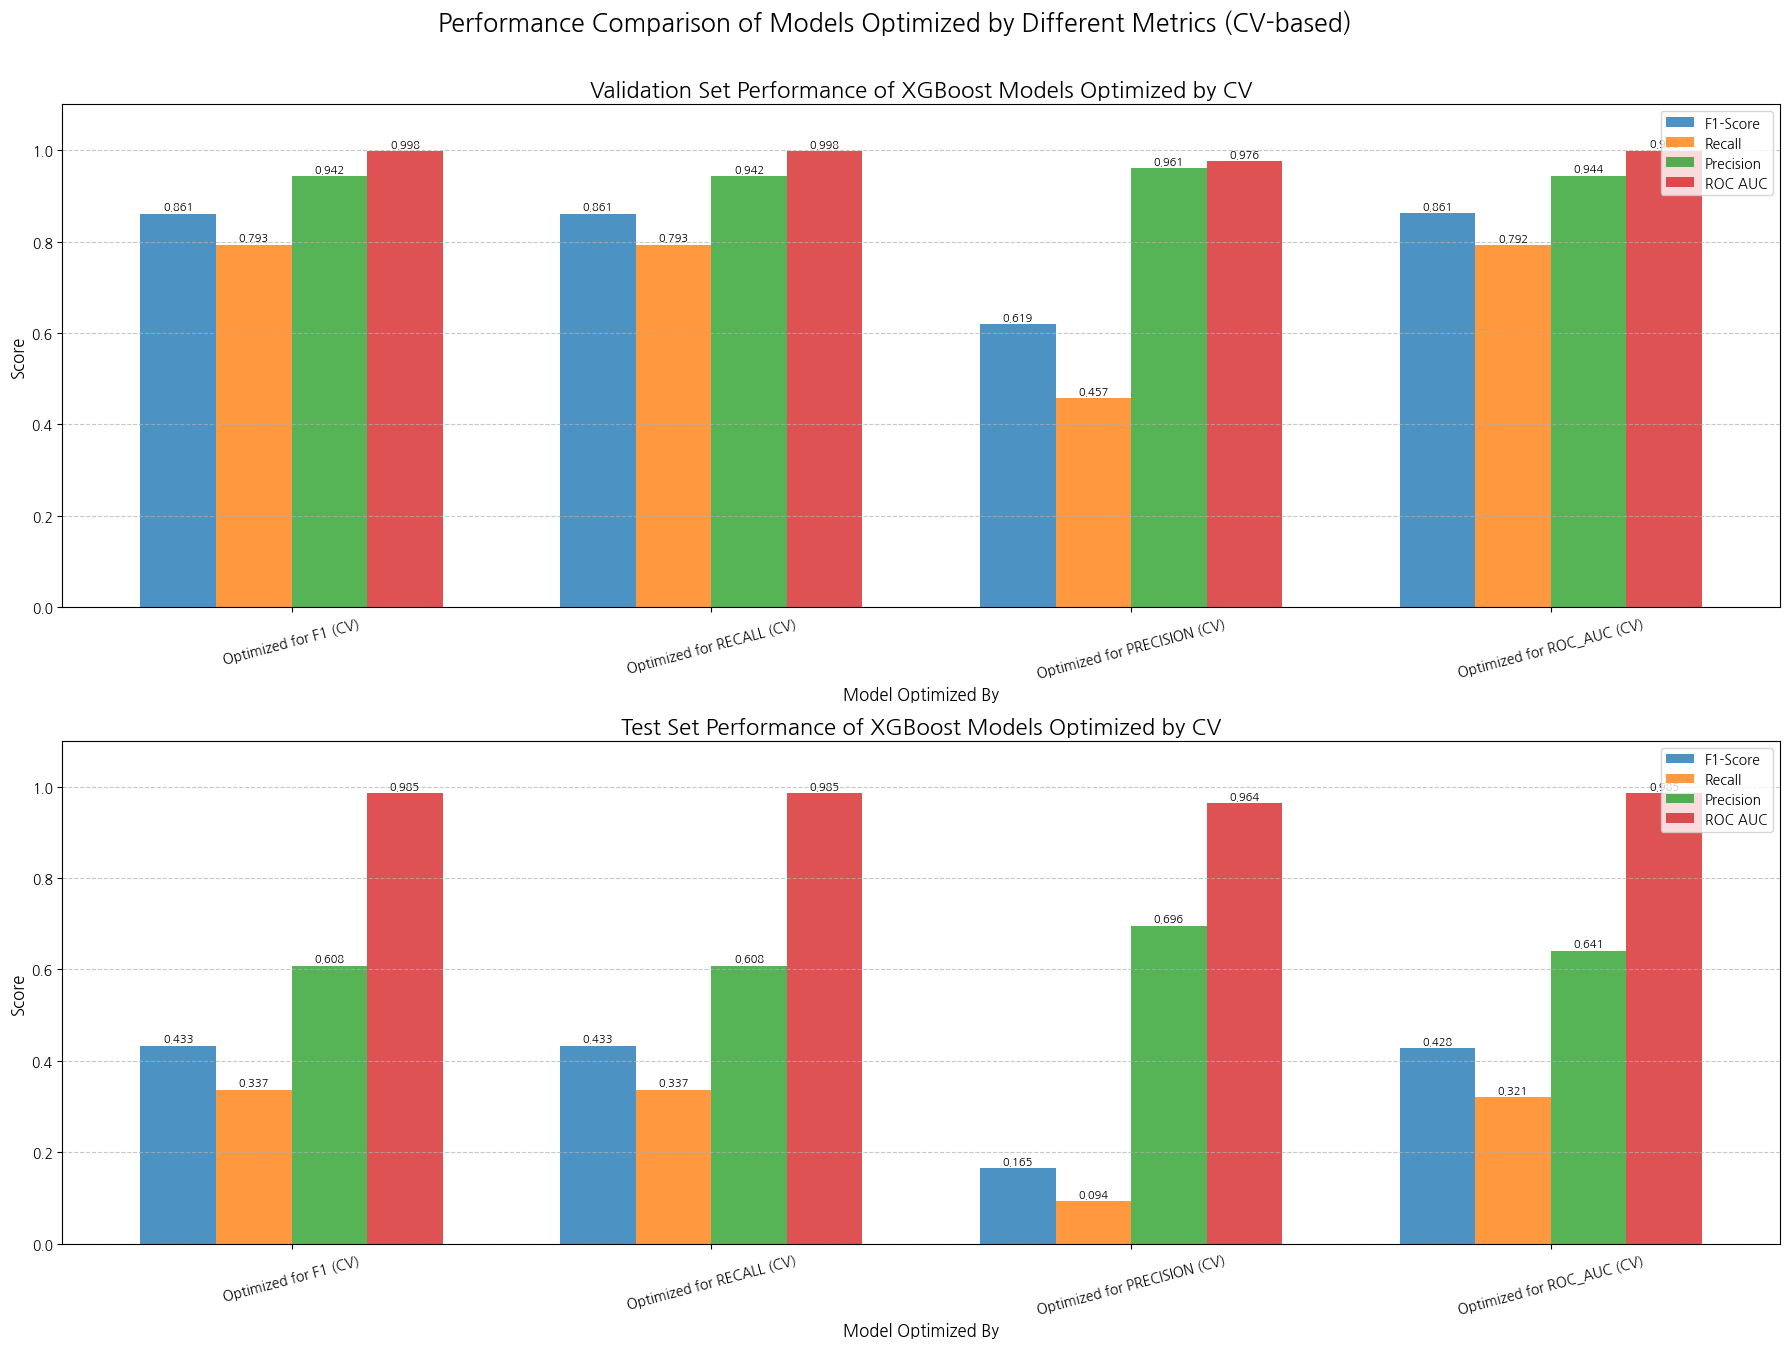

In [ ]:
# --- 5. 시각화를 위한 데이터 준비 ---
# 각 모델(Optimized for F1, Recall, Precision, ROC_AUC)별로 4가지 성능 지표를 그룹화
metric_display_names = ['F1-Score', 'Recall', 'Precision', 'ROC AUC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # F1, Recall, Precision, ROC AUC 순서
metric_lookup_keys = ['f1', 'recall', 'precision', 'roc_auc']

# --- 6. 시각화 (두 개의 서브플롯: Validation 성능 / Test 성능) ---
fig, axes = plt.subplots(2, 1, figsize=(18, 14), sharey=True) # sharey=True로 y축 범위 통일

# x축 위치를 위한 인덱스 생성
x = np.arange(len(model_optimization_labels))
bar_width = 0.18 # 각 개별 막대의 너비
num_metrics_to_plot = len(metric_display_names) # 4개 (F1, Recall, Precision, ROC AUC)

# --- 첫 번째 서브플롯: Validation 성능 시각화 (상단) ---
ax1 = axes[0]
ax1.set_title('Validation Set Performance of XGBoost Models Optimized by CV', fontsize=16)
ax1.set_xlabel('Model Optimized By', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(model_optimization_labels, rotation=15, ha='center', fontsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_ylim(0, 1.1) # Y축 범위 고정
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 여기서 metric_display_names와 metric_lookup_keys를 함께 사용합니다.
for i, display_name in enumerate(metric_display_names):
    lookup_key = metric_lookup_keys[i] # 실제 딕셔너리에서 점수를 찾을 때 사용할 키

    # scores_for_plot를 가져올 때 lookup_key를 사용하도록 수정합니다.
    scores_for_plot = [validation_performance_data[m][lookup_key] for m in scoring_metrics_dict.keys()]

    offset = (i - (num_metrics_to_plot - 1) / 2) * bar_width
    bars = ax1.bar(x + offset, scores_for_plot, bar_width, label=display_name, color=colors[i], alpha=0.8)

    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3),
                 ha='center', va='bottom', fontsize=8, color='black')
ax1.legend(loc='upper right', fontsize=10)


# --- 두 번째 서브플롯: Test 성능 시각화 (하단) ---
ax2 = axes[1]
ax2.set_title('Test Set Performance of XGBoost Models Optimized by CV', fontsize=16)
ax2.set_xlabel('Model Optimized By', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(model_optimization_labels, rotation=15, ha='center', fontsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.set_ylim(0, 1.1) # Y축 범위 고정
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 여기서도 metric_display_names와 metric_lookup_keys를 함께 사용합니다.
for i, display_name in enumerate(metric_display_names):
    lookup_key = metric_lookup_keys[i] # 실제 딕셔너리에서 점수를 찾을 때 사용할 키

    # scores_for_plot를 가져올 때 lookup_key를 사용하도록 수정합니다.
    scores_for_plot = [test_performance_data[m][lookup_key] for m in scoring_metrics_dict.keys()]

    offset = (i - (num_metrics_to_plot - 1) / 2) * bar_width
    bars = ax2.bar(x + offset, scores_for_plot, bar_width, label=display_name, color=colors[i], alpha=0.8)

    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3),
                 ha='center', va='bottom', fontsize=8, color='black')
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 전체 레이아웃 조정
plt.suptitle('Performance Comparison of Models Optimized by Different Metrics (CV-based)', fontsize=18, y=0.99)
plt.show()

In [ ]:
for metric_name, params in best_params_per_metric_cv.items():
    print(f"\n[최적화 기준: {metric_name.upper()}]")
    for param_name, param_value in params.items():
        print(f"  - {param_name}: {param_value}")
print("\n" + "="*50)


[최적화 기준: F1]
  - colsample_bytree: 0.8
  - gamma: 0.1
  - learning_rate: 0.05
  - max_depth: 7
  - min_child_weight: 1
  - n_estimators: 500
  - reg_lambda: 1.0
  - subsample: 0.8

[최적화 기준: RECALL]
  - colsample_bytree: 0.8
  - gamma: 0.1
  - learning_rate: 0.05
  - max_depth: 7
  - min_child_weight: 1
  - n_estimators: 500
  - reg_lambda: 1.0
  - subsample: 0.8

[최적화 기준: PRECISION]
  - colsample_bytree: 0.7
  - gamma: 0.1
  - learning_rate: 0.01
  - max_depth: 7
  - min_child_weight: 5
  - n_estimators: 200
  - reg_lambda: 1.0
  - subsample: 0.8

[최적화 기준: ROC_AUC]
  - colsample_bytree: 0.8
  - gamma: 0
  - learning_rate: 0.05
  - max_depth: 7
  - min_child_weight: 1
  - n_estimators: 500
  - reg_lambda: 1.0
  - subsample: 0.8





--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.942201  0.792805  0.861071  0.998039

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9997    0.9993    257834
           1     0.9422    0.7928    0.8611      1501

    accuracy                         0.9985    259335
   macro avg     0.9705    0.8963    0.9302    259335
weighted avg     0.9985    0.9985    0.9985    259335



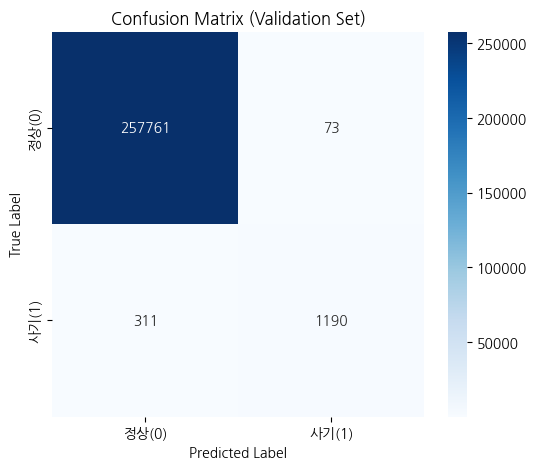



--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.608256  0.336597  0.433373  0.985456

Classification Report:
              precision    recall  f1-score   support

           0     0.9974    0.9992    0.9983    553574
           1     0.6083    0.3366    0.4334      2145

    accuracy                         0.9966    555719
   macro avg     0.8028    0.6679    0.7158    555719
weighted avg     0.9959    0.9966    0.9961    555719



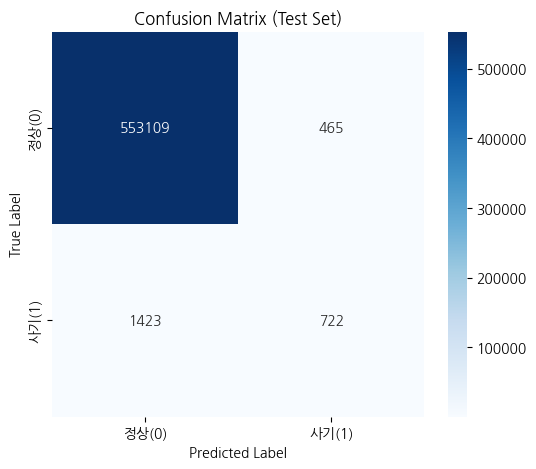

In [ ]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results = evaluate_and_visualize(saved_models_list[0], X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
test_results = evaluate_and_visualize(saved_models_list[0], X_test_scaled, y_test_final, "Test Set")

# 스태킹

In [53]:
cat_params = {
	'learning_rate': 0.1,
	'l2_leaf_reg': 3.0,
	'iterations': 500,
	'depth': 6,
	'bagging_temperature': 0.5,
	'random_state': 42,
	'verbose': 0,
  'task_type': 'GPU'
}


In [54]:
lgbm_params = {
  'boosting_type': 'gbdt',
  'n_estimators': 600,
  'learning_rate': 0.049260964924956185,
  'num_leaves': 100,
  'max_depth': 12,
  'min_child_samples': 50,
  'subsample': 0.6824196495700618,
  'colsample_bytree': 0.8255055756913129,
  'reg_alpha': 0.0047243775448650655,
  'reg_lambda': 0.0035445004741696986,
  'objective': 'binary',
  'metric': 'f1',
  'random_state': 42,
  'n_jobs': -1,
  'verbose': -1,
  'device': 'gpu'
}

In [55]:
xgb_params = {
	'n_estimators': 4944,
	'learning_rate': 0.06917383407985545,
	'max_depth': 6,
	'min_child_weight': 7,
	'gamma': 0.6919144601910644,
	'subsample': 0.7889560739409641,
	'colsample_bytree': 0.8421639076201854,
	'reg_alpha': 0.7000228879907439,
	'reg_lambda': 0.7786285622566288,
  'tree_method': 'gpu_hist',
  'predictor': 'gpu_predictor'
}


In [56]:
lgbm_clf = LGBMClassifier(**lgbm_params)
xgb_clf = XGBClassifier(**xgb_params)
cat_clf = CatBoostClassifier(**cat_params)

# 최종 모델(Meta-Learner) 정의
meta_clf = LogisticRegression(random_state=42, n_jobs=-1)

# 스태킹 모델 구성
# estimators: 1단계 모델 목록
# final_estimator: 2단계 모델
# cv: 1단계 모델들의 예측값을 생성하기 위한 교차 검증 폴드 수
stacking_model = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_clf),
        ('xgb', xgb_clf),
        ('cat', cat_clf)
    ],
    final_estimator=meta_clf,
    cv=3, # 폴드 수는 데이터 크기나 필요에 따라 조절 가능 (3 또는 5를 주로 사용)
    n_jobs=1
)

# 스태킹 모델 학습 (시간이 매우 오래 소요될 수 있습니다!)
print("\n스태킹 모델 학습을 시작합니다.")
stacking_model.fit(X_train_scaled, y_train_final)


스태킹 모델 학습을 시작합니다.


StackingClassifier(cv=3,
                   estimators=[('lgbm',
                                LGBMClassifier(colsample_bytree=0.8255055756913129,
                                               device='gpu',
                                               learning_rate=0.049260964924956185,
                                               max_depth=12, metric='f1',
                                               min_child_samples=50,
                                               n_estimators=600, n_jobs=-1,
                                               num_leaves=100,
                                               objective='binary',
                                               random_state=42,
                                               reg_alpha=0.0047243775448650655,
                                               reg_lambda=0.0035445004741696986,
                                               subsample=0.6824196...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=6,
                                              max_leaves=None,
                                              min_child_weight=7, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=4944, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7bda78074e10>)],
                   final_estimator=LogisticRegression(n_jobs=-1,
                                                      random_state=42),
                   n_jobs=1)

In [57]:
print("===== Iso + 스태킹(Stacking) 앙상블 모델 테스트 시작 =====")

# 기본 모델들 정의
lgbm_clf1 = LGBMClassifier(random_state=42, n_jobs=-1)
xgb_clf1 = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
cat_clf1 = CatBoostClassifier(random_state=42, verbose=0)

# 최종 모델(Meta-Learner) 정의
meta_clf1 = LogisticRegression(random_state=42, n_jobs=-1)

# 스태킹 모델 구성
# estimators: 1단계 모델 목록
# final_estimator: 2단계 모델
# cv: 1단계 모델들의 예측값을 생성하기 위한 교차 검증 폴드 수
stacking_model1 = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_clf1),
        ('xgb', xgb_clf1),
        ('cat', cat_clf1)
    ],
    final_estimator=meta_clf1,
    # cv=3, # 폴드 수는 데이터 크기나 필요에 따라 조절 가능 (3 또는 5를 주로 사용)
    n_jobs=1
)

# 스태킹 모델 학습 (시간이 매우 오래 소요될 수 있습니다!)
print("\n스태킹 모델 학습을 시작합니다.")
stacking_model1.fit(X_train_scaled, y_train_final)

===== Iso + 스태킹(Stacking) 앙상블 모델 테스트 시작 =====

스태킹 모델 학습을 시작합니다.


StackingClassifier(estimators=[('lgbm',
                                LGBMClassifier(n_jobs=-1, random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=-1,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7bda2fa69490>)],
                   final_estimator=LogisticRegression(n_jobs=-1,
                                                      random_state=42),
                   n_jobs=1)



--- Validation Set 평가 결과 ---
   Precision   Recall  F1-Score   ROC_AUC
0   0.959969  0.81479  0.881441  0.998003

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9998    0.9994    257834
           1     0.9600    0.8148    0.8814      1501

    accuracy                         0.9987    259335
   macro avg     0.9794    0.9073    0.9404    259335
weighted avg     0.9987    0.9987    0.9987    259335



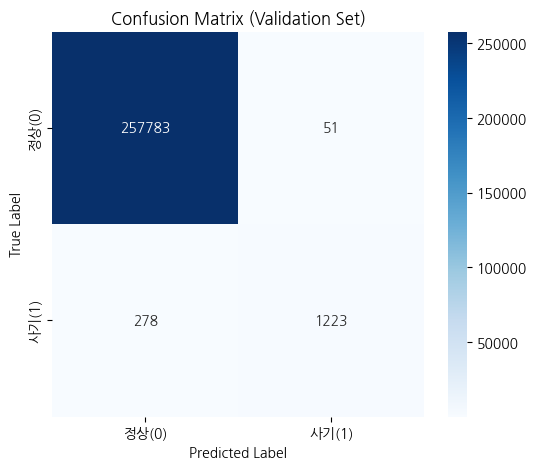



--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.915921  0.477389  0.627643  0.986152

Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9998    0.9989    553574
           1     0.9159    0.4774    0.6276      2145

    accuracy                         0.9978    555719
   macro avg     0.9570    0.7386    0.8133    555719
weighted avg     0.9977    0.9978    0.9975    555719



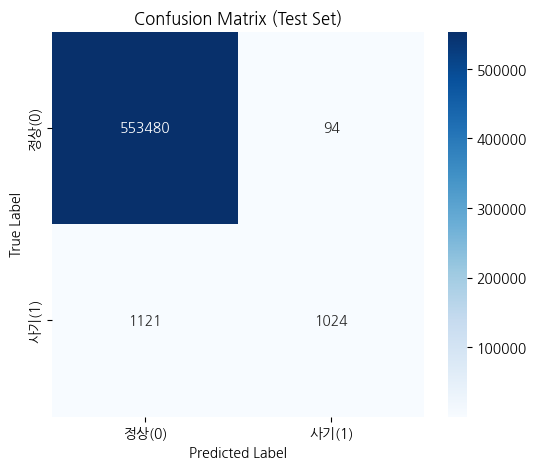

In [58]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results = evaluate_and_visualize(stacking_model, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
test_results = evaluate_and_visualize(stacking_model, X_test_scaled, y_test_final, "Test Set")



--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.951687  0.826782  0.884848  0.997567

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9998    0.9994    257834
           1     0.9517    0.8268    0.8848      1501

    accuracy                         0.9988    259335
   macro avg     0.9753    0.9133    0.9421    259335
weighted avg     0.9987    0.9988    0.9987    259335



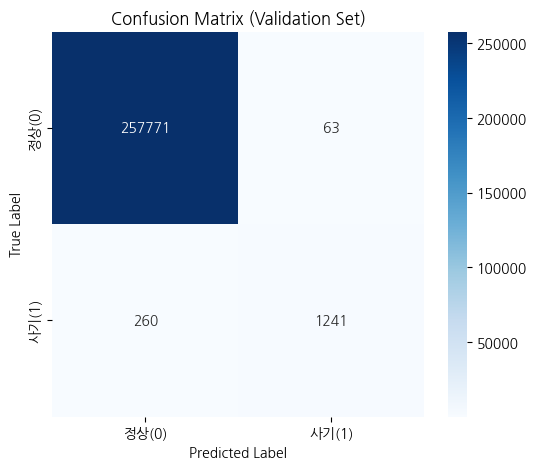



--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.885841  0.466667  0.611298  0.982868

Classification Report:
              precision    recall  f1-score   support

           0     0.9979    0.9998    0.9989    553574
           1     0.8858    0.4667    0.6113      2145

    accuracy                         0.9977    555719
   macro avg     0.9419    0.7332    0.8051    555719
weighted avg     0.9975    0.9977    0.9974    555719



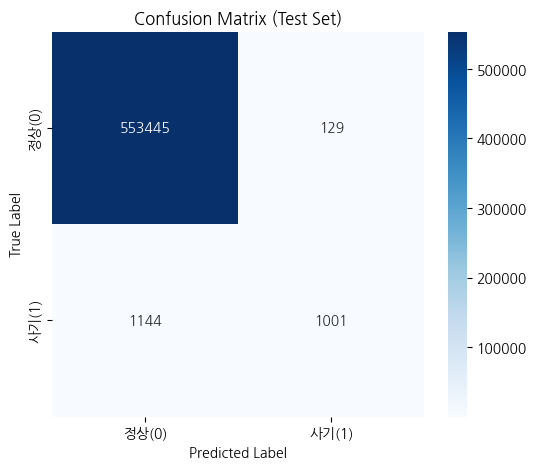

In [59]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results1 = evaluate_and_visualize(stacking_model1, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
test_results1 = evaluate_and_visualize(stacking_model1, X_test_scaled, y_test_final, "Test Set")

In [60]:
import plotly.graph_objects as go

# --- 1. 모델 선택 ---
# 튜닝을 통해 얻은 모델을 사용합니다.
# 만약 베이스라인 모델로 하고 싶다면 model_to_tune = baseline_model 로 변경하세요.
model_to_tune = stacking_model

# --- 2. 검증 데이터셋에 대한 예측 확률 계산 ---
# (Positive 클래스, 즉 '사기일 확률'만 가져옵니다)
val_preds_proba = model_to_tune.predict_proba(X_val_scaled)[:, 1]

# --- 3. 최적 임계값 탐색 ---
thresholds = np.arange(0.01, 1.0, 0.01) # 0.01부터 0.99까지 0.01 간격으로 테스트
f1_scores = []

# 각 임계값마다 F1 Score 계산
for thresh in thresholds:
    # 임계값 기준으로 예측 (0 또는 1)
    preds_binary = (val_preds_proba >= thresh).astype(int)
    # F1 Score 계산 후 저장
    f1 = f1_score(y_val_final, preds_binary)
    f1_scores.append(f1)

# 가장 높은 F1 Score를 기록한 임계값과 점수 찾기
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"최적 임계값 (Optimal Threshold): {best_threshold:.2f}")
print(f"해당 임계값에서의 검증 데이터 F1-Score: {best_f1:.4f}")

# --- 4. 임계값 변화에 따른 F1-Score 시각화 ---
fig = go.Figure()

# 전체 임계값-F1 Score 라인
fig.add_trace(go.Scatter(
    x=thresholds,
    y=f1_scores,
    mode='lines',
    name='F1-Score'
))

# 가장 높은 지점에 점과 텍스트 추가
fig.add_trace(go.Scatter(
    x=[best_threshold],
    y=[best_f1],
    mode='markers+text',
    marker=dict(color='red', size=10),
    text=[f"Best F1: {best_f1:.4f}<br>Thresh: {best_threshold:.2f}"],
    textposition="top center",
    name='Optimal Point'
))

fig.update_layout(
    title='최적 임계값(Threshold)에 따른 F1-Score 변화',
    xaxis_title='임계값 (Threshold)',
    yaxis_title='F1-Score',
    template='plotly_white'
)

fig.show()

최적 임계값 (Optimal Threshold): 0.12
해당 임계값에서의 검증 데이터 F1-Score: 0.8900


In [63]:
def evaluate_and_visualize(model, X_data, y_data, set_name, threshold=0.5):
    """모델 평가 및 결과/혼동 행렬 시각화 함수"""
    y_pred_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    results = {
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred),
        'ROC_AUC': roc_auc_score(y_data, y_pred_proba)
    }

    print(f"\n--- {set_name} 평가 결과 (적용된 임계값: {threshold:.2f}) ---")
    print(pd.DataFrame([results]).to_string())
    print("\nClassification Report:")
    print(classification_report(y_data, y_pred, digits=4))

    cm = confusion_matrix(y_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'])
    plt.title(f'Confusion Matrix ({set_name})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return results



--- Validation Set 평가 결과 (적용된 임계값: 0.12) ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.938655  0.846103  0.889979  0.998003

Classification Report:
              precision    recall  f1-score   support

           0     0.9991    0.9997    0.9994    257834
           1     0.9387    0.8461    0.8900      1501

    accuracy                         0.9988    259335
   macro avg     0.9689    0.9229    0.9447    259335
weighted avg     0.9988    0.9988    0.9988    259335



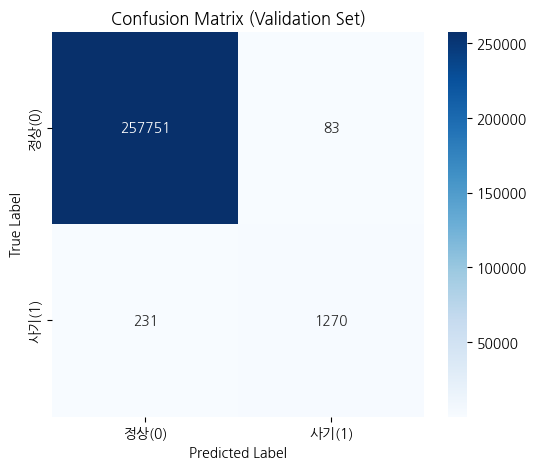



--- Test Set 평가 결과 (적용된 임계값: 0.12) ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.869434  0.537063  0.663977  0.986152

Classification Report:
              precision    recall  f1-score   support

           0     0.9982    0.9997    0.9989    553574
           1     0.8694    0.5371    0.6640      2145

    accuracy                         0.9979    555719
   macro avg     0.9338    0.7684    0.8315    555719
weighted avg     0.9977    0.9979    0.9977    555719



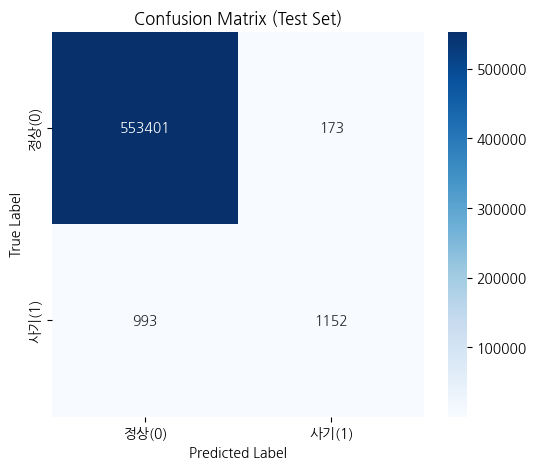

In [64]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results = evaluate_and_visualize(stacking_model, X_val_scaled, y_val_final, "Validation Set", 0.12)

# 테스트 데이터 평가
print("\n" + "="*50)
test_results = evaluate_and_visualize(stacking_model, X_test_scaled, y_test_final, "Test Set", 0.12)